# Lab 2 Part 1 - Series de Tiempo
En este laboratorio modelamos la dinamica de precios con rigor estadistico. Para una serie temporal de precios de cierre $P_t$, definimos la variacion por hora como $\Delta P_t = P_t - P_{t-1}$.

La naturaleza estocastica de la fluctuacion de precios se puede interpretar con:
$$\Delta P_t = \mu \Delta t + \sigma \sqrt{\Delta t}\,\varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)$$
donde $\mu$ representa el drift medio y $\sigma$ la intensidad de ruido del proceso.

**Aclaración Metodológica:** Este laboratorio fue desarrollado utilizando la metodología de **Vibe Coding** con asistencia de Inteligencia Artificial (GitHub Copilot / GPT-5.3-Codex), priorizando el diseño de la arquitectura (Engine/Runner) y el rigor matemático de la *Física de Datos* sobre la escritura manual de sintaxis.

> 1. Leer el dataset desde el github.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

from src.kinematics import TimeSeriesEngine

DATA_URL = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"
RAW_PATH = Path("../data/raw/eur_usd.csv")
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_URL)
df_raw.to_csv(RAW_PATH, index=False)

print("--- Respuestas al Laboratorio 2 Parte 1 ---")
print(f"1. Dataset leído desde GitHub y guardado en: {RAW_PATH}")
print(f"   Registros: {df_raw.shape[0]}, Columnas: {df_raw.shape[1]}")
print(df_raw.head())

--- Respuestas al Laboratorio 2 Parte 1 ---
1. Dataset leído desde GitHub y guardado en: ../data/raw/eur_usd.csv
   Registros: 5000, Columnas: 13
   Unnamed: 0                 time     open     high      low    close  \
0           0  2022-07-25 13:00:00  1.02427  1.02430  1.02145  1.02345   
1           1  2022-07-25 14:00:00  1.02345  1.02578  1.02288  1.02299   
2           2  2022-07-25 15:00:00  1.02303  1.02476  1.02230  1.02457   
3           3  2022-07-25 16:00:00  1.02454  1.02548  1.02355  1.02485   
4           4  2022-07-25 17:00:00  1.02485  1.02514  1.02030  1.02181   

   tick_volume  spread  real_volume  MeanCloseOpen  Diff_Close  Diff_Open  \
0         3927       8            0       1.023860    -0.00046   -0.00082   
1         5344       8            0       1.023220    -0.00046   -0.00082   
2         5524       8            0       1.023800     0.00158   -0.00042   
3         5234       8            0       1.024695     0.00028    0.00151   
4         9031       7  

> 2. Definir como indice la columna time.

In [2]:
engine = TimeSeriesEngine(df_raw)
engine.normalize_columns_pascal_case()
engine.set_time_index("Time")

print("2. La columna Time fue definida como índice temporal del sistema.")
print(f"   Tipo de índice: {type(engine.DataFrame.index).__name__}")
print(engine.DataFrame.head())

2. La columna Time fue definida como índice temporal del sistema.
   Tipo de índice: DatetimeIndex
                     Unnamed0     Open     High      Low    Close  TickVolume  \
Time                                                                            
2022-07-25 13:00:00         0  1.02427  1.02430  1.02145  1.02345        3927   
2022-07-25 14:00:00         1  1.02345  1.02578  1.02288  1.02299        5344   
2022-07-25 15:00:00         2  1.02303  1.02476  1.02230  1.02457        5524   
2022-07-25 16:00:00         3  1.02454  1.02548  1.02355  1.02485        5234   
2022-07-25 17:00:00         4  1.02485  1.02514  1.02030  1.02181        9031   

                     Spread  RealVolume  MeanCloseOpen  DiffClose  DiffOpen  \
Time                                                                          
2022-07-25 13:00:00       8           0       1.023860   -0.00046  -0.00082   
2022-07-25 14:00:00       8           0       1.023220   -0.00046  -0.00082   
2022-07-25 15:00:

> 3. Obtenga información del data frame.

In [3]:
frame_info = engine.get_data_frame_info()

print("3. Información estructural del DataFrame:")
print(f"   Filas: {frame_info['Shape']['Rows']}")
print(f"   Columnas: {frame_info['Shape']['Columns']}")
print("   Tipos de datos:")
for col, dtype in frame_info["Dtypes"].items():
    print(f"   - {col}: {dtype}")

3. Información estructural del DataFrame:
   Filas: 5000
   Columnas: 12
   Tipos de datos:
   - Unnamed0: int64
   - Open: float64
   - High: float64
   - Low: float64
   - Close: float64
   - TickVolume: int64
   - Spread: int64
   - RealVolume: int64
   - MeanCloseOpen: float64
   - DiffClose: float64
   - DiffOpen: float64
   - DiffMeanCloseOpen: float64


> 4. Determine si hay null, nan en el data frame.

In [4]:
null_report = engine.get_null_nan_report()

print("4. Evaluación de valores null/NaN:")
print(f"   Total null/NaN: {null_report['TotalNullOrNaN']}")
print("   Conteo por columna:")
for col, count in null_report["NullOrNaNByColumn"].items():
    print(f"   - {col}: {count}")

4. Evaluación de valores null/NaN:
   Total null/NaN: 0
   Conteo por columna:
   - Unnamed0: 0
   - Open: 0
   - High: 0
   - Low: 0
   - Close: 0
   - TickVolume: 0
   - Spread: 0
   - RealVolume: 0
   - MeanCloseOpen: 0
   - DiffClose: 0
   - DiffOpen: 0
   - DiffMeanCloseOpen: 0


> 5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.

In [5]:
engine.normalize_columns_pascal_case()
engine.keep_only_close_price("Close")

print("5. Se mantiene notación PascalCase y se trabaja solo con el precio de cierre EUR/USD.")
print(f"   Columnas activas: {engine.DataFrame.columns.tolist()}")
print(engine.DataFrame.head())

5. Se mantiene notación PascalCase y se trabaja solo con el precio de cierre EUR/USD.
   Columnas activas: ['Close']
                       Close
Time                        
2022-07-25 13:00:00  1.02345
2022-07-25 14:00:00  1.02299
2022-07-25 15:00:00  1.02457
2022-07-25 16:00:00  1.02485
2022-07-25 17:00:00  1.02181


> 6. Determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora (DiffPrice):
> 
> - Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice.
> - Para la nueva columna construya un histograma de los datos.
> - Determine la mejor distribucion estadística (fitter) entre [gamma, lognorm, beta, burr, norm].

6.1 Se calculó la diferencia horaria en la columna DiffPrice.
                       Close  DiffPrice
Time                                   
2022-07-25 13:00:00  1.02345        NaN
2022-07-25 14:00:00  1.02299   -0.00046
2022-07-25 15:00:00  1.02457    0.00158
2022-07-25 16:00:00  1.02485    0.00028
2022-07-25 17:00:00  1.02181   -0.00304


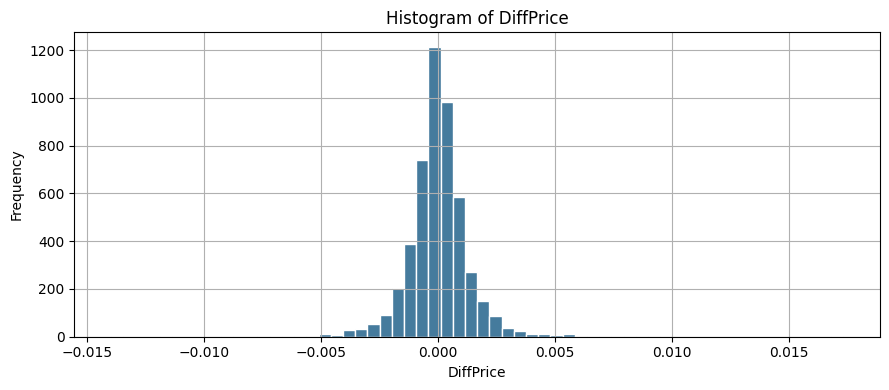

6.2 Histograma de DiffPrice generado.


2026-04-16 11:07:08.763 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=106677.525909, AIC=-51503.23, KS=0.0908
2026-04-16 11:07:08.774 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=923360.482403, AIC=-17723.24, KS=0.5914
2026-04-16 11:07:08.873 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106744.023571, AIC=-51505.72, KS=0.0905
2026-04-16 11:07:09.000 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=106500.661168, AIC=-51509.77, KS=0.0916
2026-04-16 11:07:09.175 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted burr: error=721804.561088, AIC=-37765.25, KS=0.3864


6.3 Mejor distribución ajustada (fitter):
{'BestDistribution': 'lognorm', 'Parameters': {'s': 0.009509964461157715, 'loc': -0.1471693008245066, 'scale': 0.14717494036949658}, 'AllSSE': {'lognorm': 106500.66116836156, 'beta': 106677.525909416, 'norm': 106744.02357126417, 'burr': 721804.5610880618, 'gamma': 923360.4824031572}}


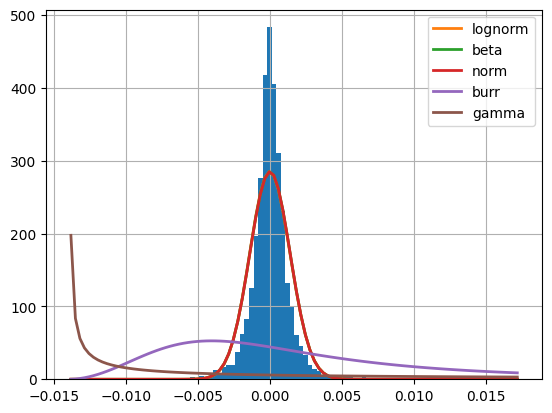

In [6]:
engine.add_diff_price(close_column="Close", diff_column="DiffPrice")

print("6.1 Se calculó la diferencia horaria en la columna DiffPrice.")
print(engine.DataFrame[["Close", "DiffPrice"]].head())

plt.figure(figsize=(9, 4))
engine.DataFrame["DiffPrice"].dropna().hist(bins=60, color="#457b9d", edgecolor="white")
plt.title("Histogram of DiffPrice")
plt.xlabel("DiffPrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("6.2 Histograma de DiffPrice generado.")

best_fit = engine.get_best_distribution("DiffPrice", ["gamma", "lognorm", "beta", "burr", "norm"])
print("6.3 Mejor distribución ajustada (fitter):")
print(best_fit)

> 7. Para el data frame, seleccionemos solo los datos del 2023.

In [7]:
engine_2023 = TimeSeriesEngine(engine.DataFrame.copy())
engine_2023.filter_year(2023)

print("7. Se seleccionaron únicamente los datos correspondientes al año 2023.")
print(f"   Filas 2023: {engine_2023.DataFrame.shape[0]}")
print(engine_2023.DataFrame.head())

7. Se seleccionaron únicamente los datos correspondientes al año 2023.
   Filas 2023: 2278
                       Close  DiffPrice
Time                                   
2023-01-02 00:00:00  1.06796   -0.00200
2023-01-02 01:00:00  1.06965    0.00169
2023-01-02 02:00:00  1.07058    0.00093
2023-01-02 03:00:00  1.06896   -0.00162
2023-01-02 04:00:00  1.06880   -0.00016


> 8. El comando groupby permite agrupar los datos con la periodicidad deseada: 15 dias, 1 semana, y 1 mes. Determina el promedio.

In [8]:
grouped_means = engine_2023.grouped_mean_close("Close")

print("8. Promedios de Close por periodicidad (15 días, 1 semana, 1 mes):")
for period, series in grouped_means.items():
    print(f"\n   {period} -> primeras filas")
    print(series.head())

8. Promedios de Close por periodicidad (15 días, 1 semana, 1 mes):

   15D -> primeras filas
Time
2023-01-02    1.069361
2023-01-17    1.085565
2023-02-01    1.077679
2023-02-16    1.063150
2023-03-03    1.063186
Freq: 15D, Name: Close, dtype: float64

   1W -> primeras filas
Time
2023-01-08    1.059972
2023-01-15    1.076002
2023-01-22    1.082041
2023-01-29    1.088414
2023-02-05    1.089281
Freq: W-SUN, Name: Close, dtype: float64

   1M -> primeras filas
Time
2023-01-31    1.077463
2023-02-28    1.071167
2023-03-31    1.070874
2023-04-30    1.096051
2023-05-31    1.098980
Freq: ME, Name: Close, dtype: float64


> 9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.

In [9]:
hist_paths = engine_2023.monthly_histograms(2023, close_column="Close", output_dir="../artifacts/lab02_monthly_hist")

print("9. Histogramas mensuales para 2023 generados.")
print(f"   Total de histogramas guardados: {len(hist_paths)}")
print("   Primeros archivos:")
for path in hist_paths[:5]:
    print(f"   - {path}")

9. Histogramas mensuales para 2023 generados.
   Total de histogramas guardados: 5
   Primeros archivos:
   - ../artifacts/lab02_monthly_hist/hist_2023_01.png
   - ../artifacts/lab02_monthly_hist/hist_2023_02.png
   - ../artifacts/lab02_monthly_hist/hist_2023_03.png
   - ../artifacts/lab02_monthly_hist/hist_2023_04.png
   - ../artifacts/lab02_monthly_hist/hist_2023_05.png


> Guardar artifacto con la mejor distribucion y parametros.

In [10]:
artifact_path = Path("../artifacts/02_eurusd_stats.json")
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(best_fit, f, indent=2, ensure_ascii=False)

print("Resultado final: artifact de distribución guardado correctamente.")
print(f"Ruta: {artifact_path}")
print(f"Mejor distribución: {best_fit['BestDistribution']}")
artifact_path

Resultado final: artifact de distribución guardado correctamente.
Ruta: ../artifacts/02_eurusd_stats.json
Mejor distribución: lognorm


PosixPath('../artifacts/02_eurusd_stats.json')